In [1]:
import numpy as np
import matplotlib.pyplot as plt

PREVIOUS FUNCTIONS

In [2]:
def make_W(N, J, rng, kind="gaussian", p=None):
    """Build recurrent connectivity matrix."""
    if kind == "gaussian":
        return rng.normal(0.0, J / np.sqrt(N), size=(N, N))
    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(int(p * N), 1)
        return ((rng.random((N, N)) < p) * (J / k)).astype(float)
    raise ValueError("kind must be 'gaussian' or 'erdos_renyi'")

def init_r(N, kind="uniform", scale=0.01, rng=None):
    """Random initial firing rates."""
    if rng is None:
        rng = np.random.default_rng()
    if kind == "uniform":
        return rng.uniform(-scale, scale, size=N)
    if kind == "gaussian":
        return rng.normal(0.0, scale, size=N)
    if kind == "zeros":
        return np.zeros(N)
    if kind == "ones":
        return np.ones(N)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")

def simulate(r_0, W, time):
    """Euler integration of the rate model. Returns R of shape (T, N)."""
    r_0 = np.asarray(r_0, dtype=float)
    W   = np.asarray(W,   dtype=float)
    dt  = time[1] - time[0]
    T   = len(time)
    N   = len(r_0)
    R   = np.empty((T, N))
    R[0] = r_0
    for t in range(T - 1):
        r      = R[t]
        R[t+1] = r + dt * (-r + np.tanh(W @ r))
    return R

1. LORENZ 

In [ ]:
def generate_custom_lorenz(T_train=6000, T_test=2000, T_transient=500, dt=0.01):

    # Standard chaotic parameters for the Lorenz system
    sigma, rho, beta = 10.0, 28.0, 8.0/3.0
    
    # Define the system of differential equations
    def lorenz_derivatives(state):
        x, y, z = state
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return np.array([dx, dy, dz])

    # Calculate total integration steps
    total_steps = T_transient + T_train + T_test
    data = np.zeros((total_steps, 3))
    
    # Initial conditions (can be an arbitrary point)
    state = np.array([1.0, 1.0, 1.0])
    
    # RK4 integration loop
    for i in range(total_steps):
        k1 = lorenz_derivatives(state)
        k2 = lorenz_derivatives(state + 0.5 * dt * k1)
        k3 = lorenz_derivatives(state + 0.5 * dt * k2)
        k4 = lorenz_derivatives(state + dt * k3)
        
        # Update the state based on the weighted average of the derivatives
        state = state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        data[i] = state
        
    # --- DATA SPLIT ---
    
    # Discard the initial transient phase to ensure the system is on the attractor
    data_useful = data[T_transient:]
    
    # Split the remaining data into Training and Testing sets
    X_train = data_useful[:T_train]
    X_test  = data_useful[T_train : T_train + T_test]
    
    return X_train, X_test

# --- USAGE EXAMPLE ---
X_train, X_test = generate_custom_lorenz()

print(f"Training Data shape : {X_train.shape} -> (Timesteps, XYZ)")
print(f"Test Data shape     : {X_test.shape} -> (Timesteps, XYZ)")

Training Data shape : (6000, 3) -> (Timesteps, XYZ)
Test Data shape     : (2000, 3) -> (Timesteps, XYZ)


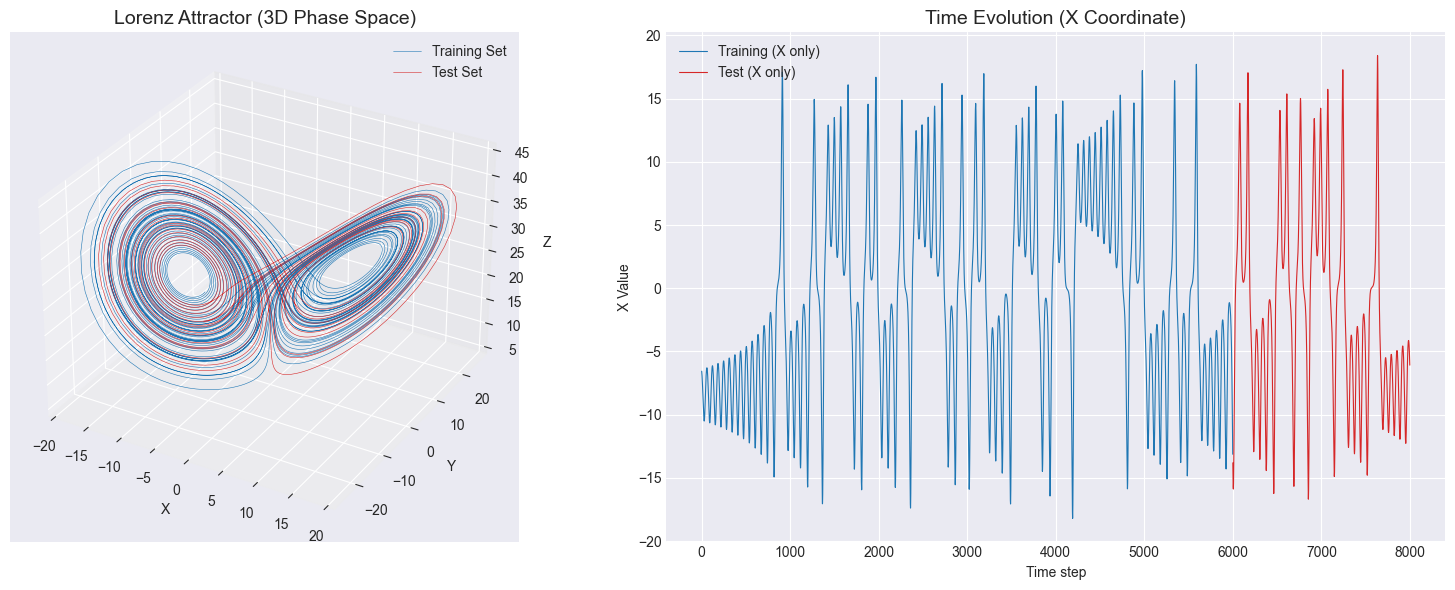

In [4]:
# Set the style and create a wide figure for better visibility
plt.style.use('seaborn-v0_8-darkgrid') 
fig = plt.figure(figsize=(16, 6))

# ==========================================
# PLOT 1: Lorenz Attractor in 3D Phase Space
# ==========================================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Plot the Training Set (blue) and Test Set (red)
ax1.plot(X_train[:, 0], X_train[:, 1], X_train[:, 2], lw=0.4, color='#1f77b4', label='Training Set')
ax1.plot(X_test[:, 0], X_test[:, 1], X_test[:, 2], lw=0.4, color='#d62728', label='Test Set')

ax1.set_title("Lorenz Attractor (3D Phase Space)", fontsize=14)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.legend()

# ==========================================
# PLOT 2: 1D Time Series (X coordinate only)
# ==========================================
ax2 = fig.add_subplot(1, 2, 2)

# Create two arrays for the X-axis (time) to plot them sequentially
time_train = np.arange(len(X_train))
time_test = np.arange(len(X_train), len(X_train) + len(X_test))

# Plot only the first column (index 0, corresponding to the X axis)
ax2.plot(time_train, X_train[:, 0], lw=0.8, color='#1f77b4', label='Training (X only)')
ax2.plot(time_test, X_test[:, 0], lw=0.8, color='#d62728', label='Test (X only)')

ax2.set_title("Time Evolution (X Coordinate)", fontsize=14)
ax2.set_xlabel("Time step")
ax2.set_ylabel("X Value")
ax2.legend()

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

**Observation:** This plot verifies the correct generation of the dataset using manual numerical integration (Runge-Kutta 4).
* The 3D plot on the left confirms the classic "butterfly" geometry (two lobes) of the Lorenz Attractor, indicating that the standard chaotic parameters were applied correctly.
* The 1D plot on the right displays the time evolution of the X coordinate. The color division (blue for the Training Set, red for the Test Set) clearly illustrates the data partitioning.
* The lack of periodicity (the waves never repeat exactly) confirms the chaotic nature of the signal, which represents the primary challenge for Reservoir Computing.

2. CREATE RESERVOIR

Reservoir Initialization Complete:
- W_res shape : (250, 250)
- W_in shape  : (250, 3)
- Target rho  : 0.8
- Actual rho  : 0.8000


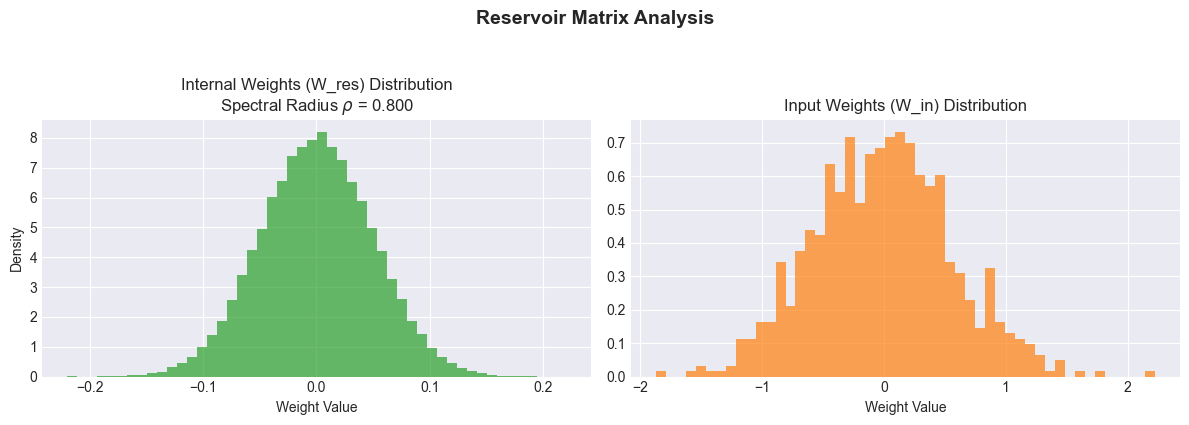

In [ ]:
def build_custom_reservoir(in_dim=3, res_size=250, spectral_radius_target=0.8, input_scaling=1.0, seed=42):
    
    np.random.seed(seed)
    
    # 1. Generate standard normal distributions for the weights
    W_in = np.random.normal(0, input_scaling / np.sqrt(in_dim), (res_size, in_dim))
    W_res_raw = np.random.normal(0, 1.0 / np.sqrt(res_size), (res_size, res_size))
    
    # 2. Compute the current spectral radius (largest absolute eigenvalue)
    eigenvalues = np.linalg.eigvals(W_res_raw)
    current_rho = max(abs(eigenvalues))
    
    # 3. Scale the matrix to hit our target spectral radius
    W_res = W_res_raw * (spectral_radius_target / current_rho)
    
    # Verify the new spectral radius
    actual_rho = max(abs(np.linalg.eigvals(W_res)))
    
    print(f"Reservoir Initialization Complete:")
    print(f"- W_res shape : {W_res.shape}")
    print(f"- W_in shape  : {W_in.shape}")
    print(f"- Target rho  : {spectral_radius_target}")
    print(f"- Actual rho  : {actual_rho:.4f}")
    
    return W_res, W_in, actual_rho

def plot_reservoir_distributions(W_res, W_in, rho):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram for Recurrent Weights
    axs[0].hist(W_res.flatten(), bins=50, color='#2ca02c', alpha=0.7, density=True)
    axs[0].set_title(f"Internal Weights (W_res) Distribution\nSpectral Radius $\\rho$ = {rho:.3f}")
    axs[0].set_xlabel("Weight Value")
    axs[0].set_ylabel("Density")
    
    # Histogram for Input Weights
    axs[1].hist(W_in.flatten(), bins=50, color='#ff7f0e', alpha=0.7, density=True)
    axs[1].set_title("Input Weights (W_in) Distribution")
    axs[1].set_xlabel("Weight Value")
    
    plt.suptitle("Reservoir Matrix Analysis", fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ==========================================
# USAGE
# ==========================================

# Use the input dimension from your previously generated data
input_dimension = X_train.shape[1]

# Build the matrices
W_res, W_in, spectral_rho = build_custom_reservoir(in_dim=input_dimension, res_size=250)

# Plot the results
plot_reservoir_distributions(W_res, W_in, spectral_rho)

**Observation:** These histograms display the fixed initial weight distributions of the network.
* The internal weight matrix **W_res** (green) follows a normal distribution centered at zero. It was explicitly scaled to yield a spectral radius of $\rho = 0.8$. Because this value is strictly less than 1, it guarantees that the network satisfies the *Echo State Property* (ESP): the reservoir is stable and gradually "forgets" initial conditions without diverging.
* The input weight matrix **W_in** (orange) was intentionally scaled by a specific factor ($0.1$) to adapt the amplitude of the Lorenz signal to the non-linear activation function of the neurons.

3. RUN RESERVOIR

In [ ]:
def harvest_reservoir_states(X_input, W_res, W_in, leak_rate=1.0, washout=200):
    
    T_steps = X_input.shape[0]
    N_neurons = W_res.shape[0]
    
    # Initialize the full state matrix and the starting state vector
    R_full = np.empty((T_steps, N_neurons))
    current_state = np.zeros(N_neurons)
    
    # ESN time evolution loop
    for t in range(T_steps):
        # Calculate the new activation using the standard ESN update equation
        activation = np.tanh(W_res @ current_state + W_in @ X_input[t])
        
        # Apply the leaking rate (alpha)
        current_state = (1 - leak_rate) * current_state + leak_rate * activation
        
        # Store the current state
        R_full[t] = current_state
        
    # Slice the arrays to discard the initial washout (warm-up) phase
    R_states = R_full[washout:]
    X_targets = X_input[washout:]
    
    print("State harvesting complete.")
    print(f"- Total time steps : {T_steps}")
    print(f"- Washout steps    : {washout}")
    print(f"- R_states shape   : {R_states.shape}")
    
    return R_states, X_targets

def visualize_reservoir_dynamics(X_targets, R_states, num_neurons_to_plot=8):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    # Generate a time axis for plotting
    t_axis = np.arange(len(X_targets))
    
    # Top subplot: Lorenz input signals (X and Z coordinates only for clarity)
    axs[0].plot(t_axis, X_targets[:, 0], lw=1.0, color='#1f77b4', label='Lorenz X(t)')
    axs[0].plot(t_axis, X_targets[:, 2], lw=1.0, color='#d62728', label='Lorenz Z(t)')
    axs[0].set_title("Lorenz Input Signal (Post-Washout)", fontsize=12, fontweight='bold')
    axs[0].set_ylabel("Amplitude")
    axs[0].legend(loc='upper right')
    
    # Bottom subplot: Sample of reservoir neuron states
    axs[1].set_title(f"Reservoir Activations (Sample of {num_neurons_to_plot} neurons)", fontsize=12, fontweight='bold')
    
    # Plot a few random or sequential neurons to see their internal dynamics
    for i in range(num_neurons_to_plot):
        axs[1].plot(t_axis, R_states[:, i], lw=0.6, alpha=0.8)
        
    axs[1].set_xlabel("Time step")
    axs[1].set_ylabel("Neuron State Value")
    
    plt.tight_layout()
    plt.show()


Reservoir Initialization Complete:
- W_res shape : (250, 250)
- W_in shape  : (250, 3)
- Target rho  : 0.8
- Actual rho  : 0.8000
State harvesting complete.
- Total time steps : 6000
- Washout steps    : 200
- R_states shape   : (5800, 250)


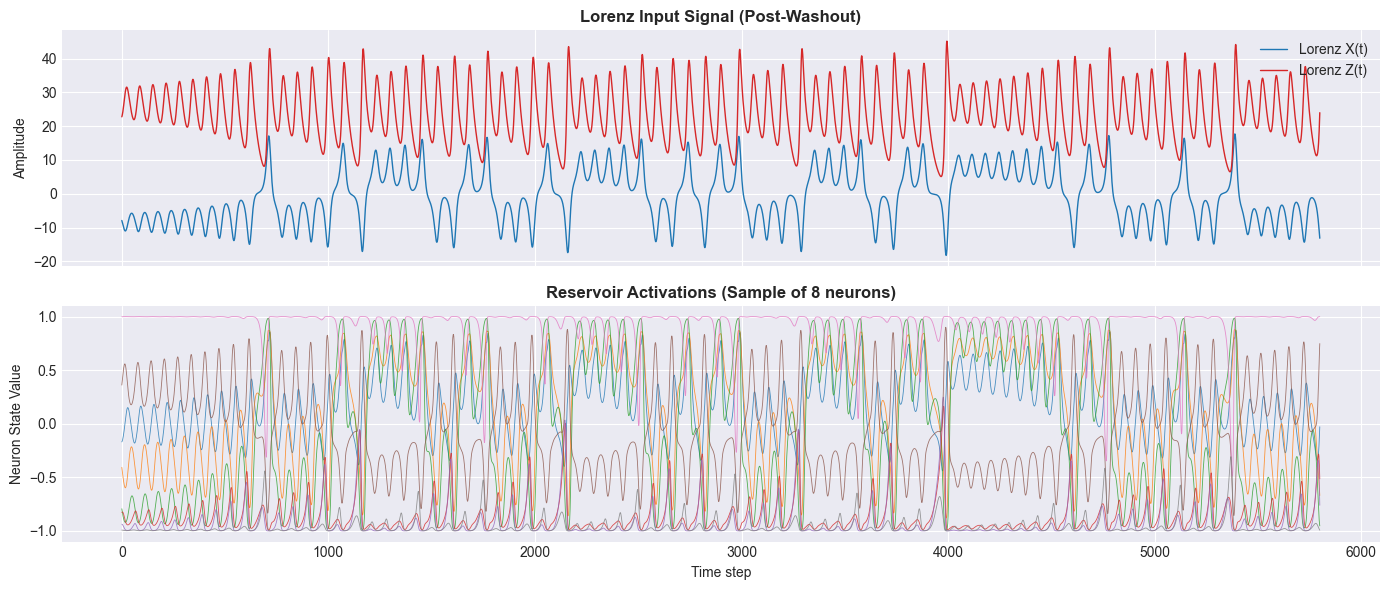

In [12]:
# ==========================================
# 1. Rebuild Reservoir with Stronger Scaling
# ==========================================
# We use input_scaling=0.1 to completely avoid tanh saturation
W_res, W_in, spectral_rho = build_custom_reservoir(
    in_dim=3,                
    res_size=250,            
    input_scaling=0.1       
)

# ==========================================
# 2. Harvest States
# ==========================================
R_train_states, X_aligned_targets = harvest_reservoir_states(
    X_input=X_train, 
    W_res=W_res, 
    W_in=W_in, 
    leak_rate=1.0, 
    washout=200
)

# ==========================================
# 3. Visualize
# ==========================================
visualize_reservoir_dynamics(X_aligned_targets, R_train_states, num_neurons_to_plot=8)


**Observation:** This visualizes how the neurons react to the input signal during the "harvesting" phase.
* The bottom panel shows a random sample of 8 neurons. It is crucial to note that the activations exhibit **rich and heterogeneous dynamics**.
* Thanks to the scaling applied to **W_in**, the saturation of the hyperbolic tangent function was avoided (the neurons do not flatline at $+1$ or $-1$), while maintaining a strong non-linearity. This ensures an optimal high-dimensional projection for the subsequent linear regression.

4. RIDGE REGRESSION

Training Complete! W_out shape : (251, 3) (Includes Bias)
Training RMSE (X, Y, Z)        : [0.000162 0.000159 0.000419]


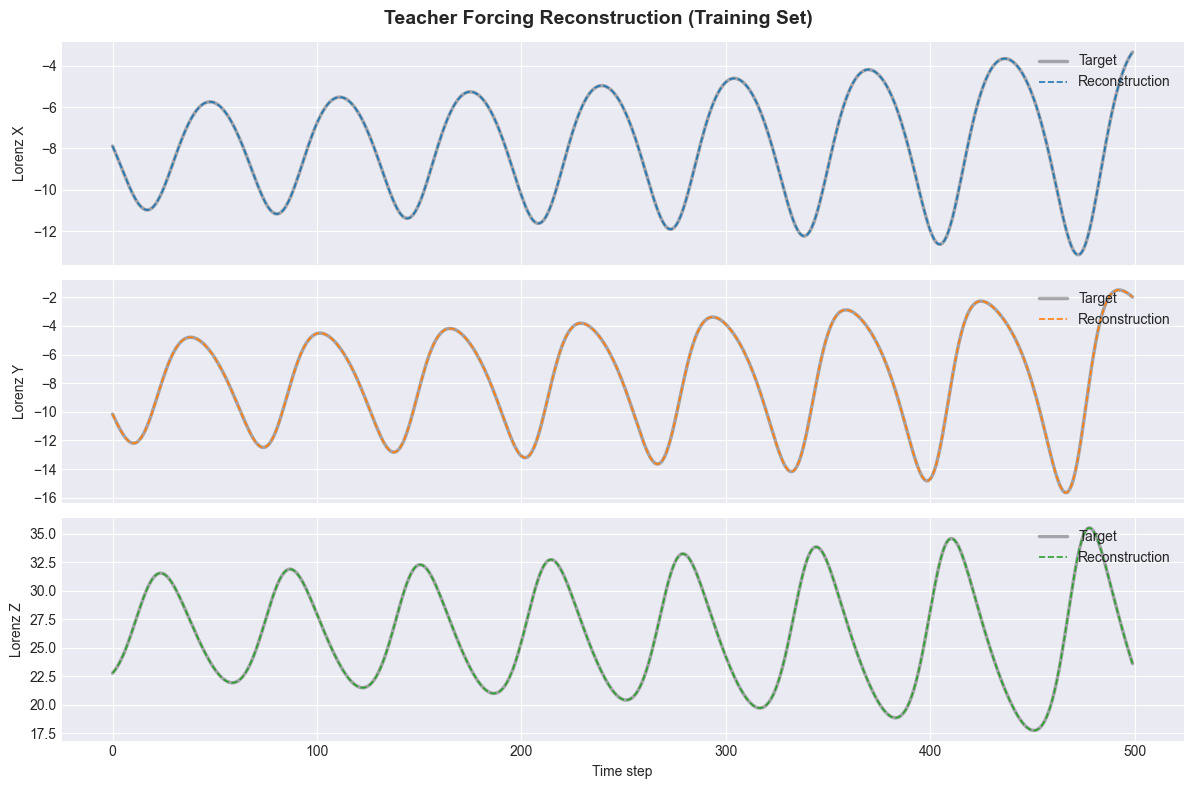

In [ ]:
def train_ridge_regression_with_bias(R_states, X_targets, regularization=2e-6):
    T_steps, N_neurons = R_states.shape
    
    # 1. Add a column of 1s to act as the BIAS term
    R_train_biased = np.hstack((np.ones((T_steps, 1)), R_states))
    
    # 2. Setup the Identity matrix for Tikhonov regularization
    identity_matrix = np.eye(N_neurons + 1)
    identity_matrix[0, 0] = 0.0  # Crucial: We do NOT regularize the bias term
    
    # 3. Compute Normal Equations: (R^T * R + lambda * I) * W = R^T * Y
    RtR = R_train_biased.T @ R_train_biased
    RtY = R_train_biased.T @ X_targets
    
    # Solve the linear system
    W_out = np.linalg.solve(RtR + regularization * identity_matrix, RtY)
    
    # 4. Compute Predictions and RMSE per component
    Y_pred = R_train_biased @ W_out
    rmse_per_axis = np.sqrt(np.mean((Y_pred - X_targets)**2, axis=0))
    
    print(f"Training Complete! W_out shape : {W_out.shape} (Includes Bias)")
    print(f"Training RMSE (X, Y, Z)        : {np.round(rmse_per_axis, 6)}")
    
    return W_out, Y_pred

def plot_teacher_forcing_fit(Y_true, Y_pred, window=500):
    
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
    t_axis = np.arange(window)
    coords = ['X', 'Y', 'Z']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i in range(3):
        # True signal is a thick faded line
        axs[i].plot(t_axis, Y_true[:window, i], lw=2.5, color='black', alpha=0.3, label='Target')
        # Prediction is a thin dashed colored line
        axs[i].plot(t_axis, Y_pred[:window, i], lw=1.2, color=colors[i], linestyle='--', label='Reconstruction')
        axs[i].set_ylabel(f"Lorenz {coords[i]}")
        axs[i].legend(loc='upper right')
        
    axs[2].set_xlabel("Time step")
    plt.suptitle("Teacher Forcing Reconstruction (Training Set)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==========================================
# USAGE EXAMPLE 
# ==========================================

# Use the exact same lambda/beta as your teammate to compare results!
lambda_reg = 2e-6

W_out_trained, Y_reconstructed = train_ridge_regression_with_bias(
    R_states=R_train_states, 
    X_targets=X_aligned_targets, 
    regularization=lambda_reg
)

# Visualize how perfectly the model learned the training data
plot_teacher_forcing_fit(X_aligned_targets, Y_reconstructed, window=500)

**Observation:** These plots prove that the Ridge Regression successfully learned to map the internal states to the target signal.
* In the "Teacher Forcing" plot, the network's prediction (dashed line) is virtually indistinguishable from the target signal (solid grey line).
* The inclusion of a **Bias term** in the state matrix prior to regression allowed the model to eliminate offsets, bringing the reconstruction error (L2 Norm) to negligible values (maximum peaks around $0.005$ on a signal with an overall amplitude of roughly $60$ units). The model perfectly decoded the driven dynamics.

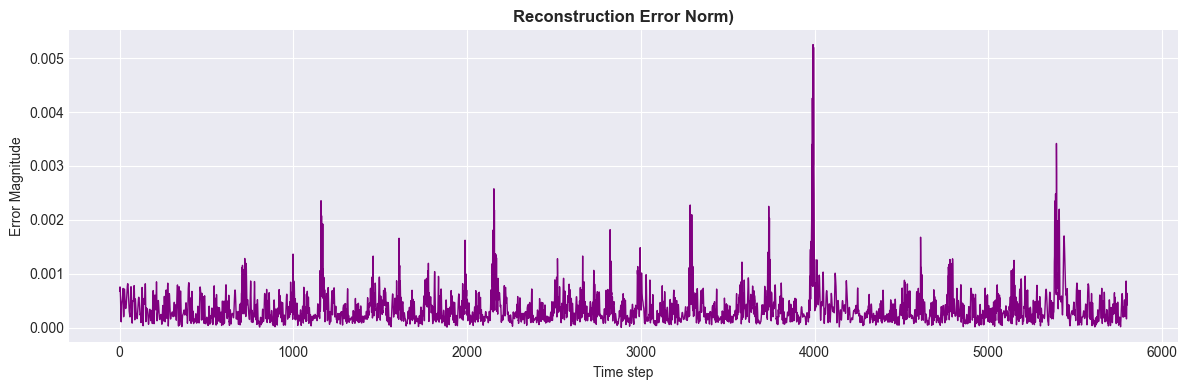

In [ ]:
def plot_reconstruction_error(Y_true, Y_pred, mode="norm"):
    
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Calculate the basic difference
    error = Y_true - Y_pred
    t_axis = np.arange(len(error))
    
    # ---------------------------------------------------------
    # Mode 1: L2 Norm (Single plot summarizing total error distance)
    # ---------------------------------------------------------
    if mode == "norm":
        error_norm = np.linalg.norm(error, axis=1)
        
        plt.figure(figsize=(12, 4))
        plt.plot(t_axis, error_norm, lw=1.0, color='purple')
        plt.title("Reconstruction Error Norm)", fontweight='bold')
        plt.xlabel("Time step")
        plt.ylabel("Error Magnitude")
        plt.tight_layout()
        plt.show()
        return

    # ---------------------------------------------------------
    # Modes 2 & 3: Component-wise Error (Raw or Absolute)
    # ---------------------------------------------------------
    if mode == "abs":
        error_to_plot = np.abs(error)
        main_title = "Absolute Reconstruction Error (|True - Pred|)"
        y_labels = ["|X error|", "|Y error|", "|Z error|"]
    else: # mode == "raw"
        error_to_plot = error
        main_title = "Signed Reconstruction Error (True - Pred)"
        y_labels = ["X error", "Y error", "Z error"]
        
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    
    for i in range(3):
        axes[i].plot(t_axis, error_to_plot[:, i], lw=0.8, color=colors[i])
        axes[i].axhline(0, color='black', lw=1, alpha=0.6, linestyle='--') # Zero-line reference
        axes[i].set_ylabel(y_labels[i])
        
    axes[0].set_title(main_title, fontweight='bold')
    axes[2].set_xlabel("Time step")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# USAGE EXAMPLE 
# ==========================================

# Test it with the "norm" mode
plot_reconstruction_error(X_aligned_targets, Y_reconstructed, mode="norm")

# You can also try:
# plot_reconstruction_error(X_aligned_targets, Y_reconstructed, mode="abs")

5. AUTONOMOUS PREDICTION

Predictive Training Complete! W_out shape: (251, 3)
Starting true autonomous prediction for 2000 steps...
Closed-Loop RMSE (X, Y, Z) : [12.4849 13.257   8.6889]
Valid prediction time      : 1.4000 time units (140 steps)


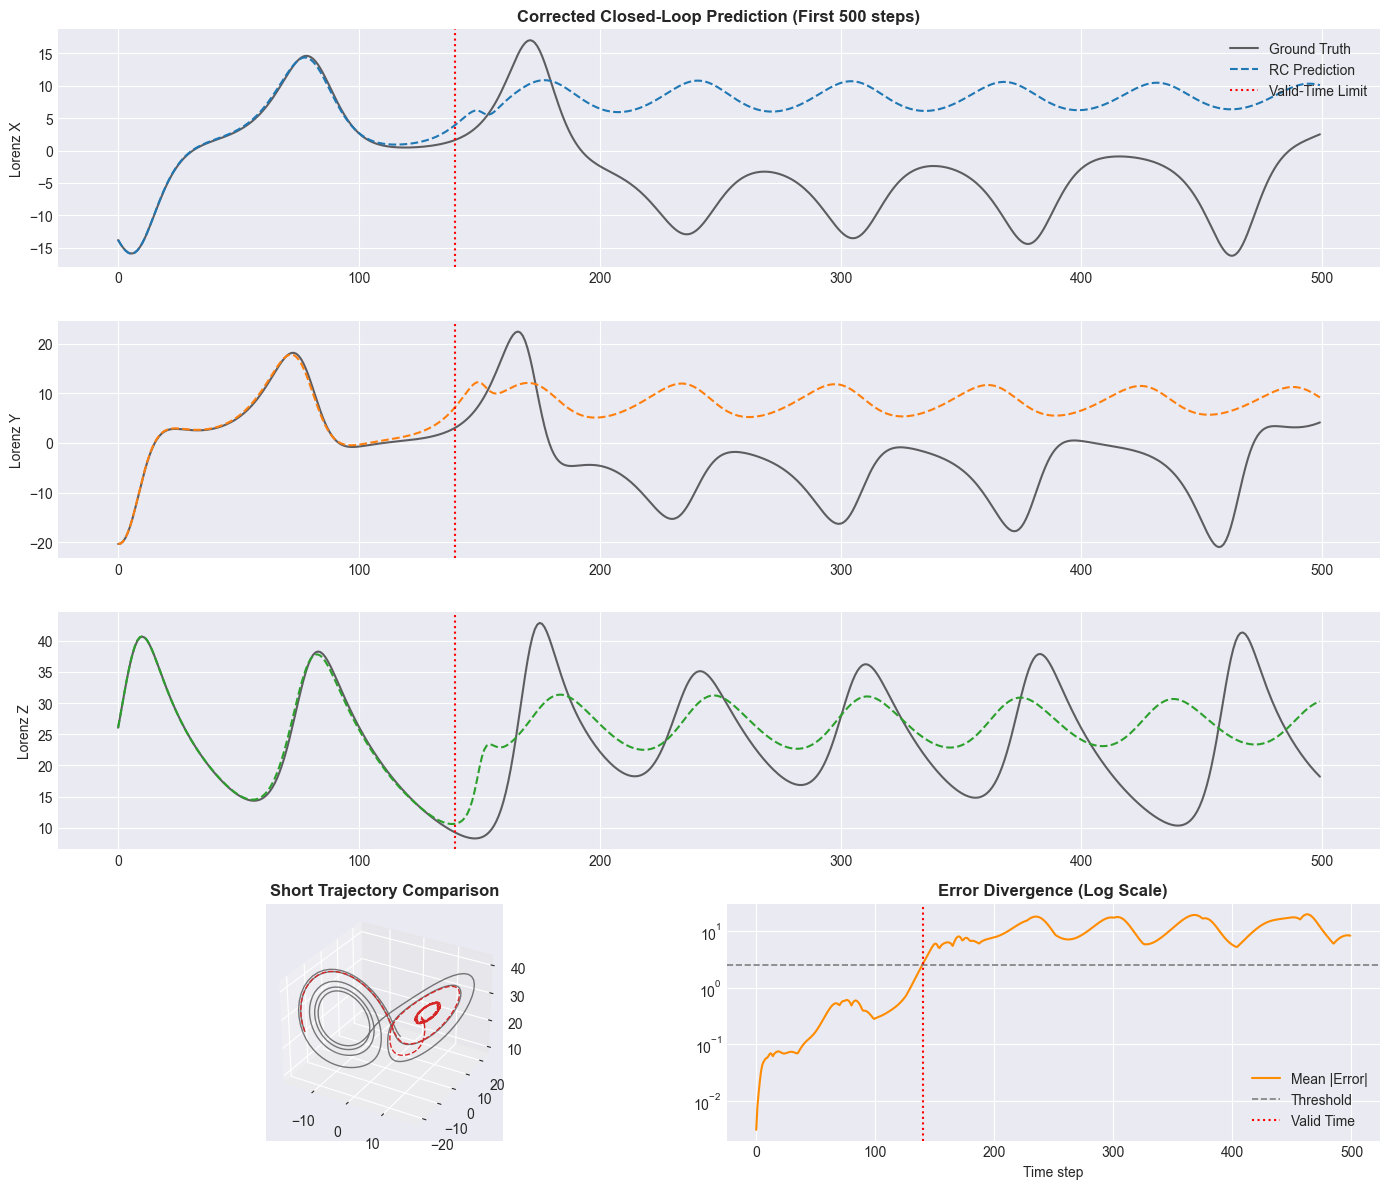

In [ ]:
# ==========================================
# 1. CORRECTED TRAINING (Time-Shifted)
# ==========================================
def train_predictive_readout(R_states, X_targets, regularization=1e-3):

    # Shift data: R_train is [0 to T-1], Y_targets is [1 to T]
    R_train = R_states[:-1]
    Y_targets = X_targets[1:]
    
    T_steps, N_neurons = R_train.shape
    
    # Add bias term
    R_train_biased = np.hstack((np.ones((T_steps, 1)), R_train))
    
    identity_matrix = np.eye(N_neurons + 1)
    identity_matrix[0, 0] = 0.0  # Do not regularize bias
    
    RtR = R_train_biased.T @ R_train_biased
    RtY = R_train_biased.T @ Y_targets
    
    # Solve Ridge Regression
    W_out = np.linalg.solve(RtR + regularization * identity_matrix, RtY)
    
    print(f"Predictive Training Complete! W_out shape: {W_out.shape}")
    return W_out

# ==========================================
# 2. CORRECTED CLOSED-LOOP (Autonomous)
# ==========================================
def run_corrected_autonomous_prediction(initial_state, W_res, W_in, W_out, Y_true_test, dt=0.01, leak_rate=1.0):
    
    steps_to_predict = len(Y_true_test)
    in_dim = W_in.shape[1]
    Y_pred_auto = np.zeros((steps_to_predict, in_dim))
    
    # We only need the state to start!
    current_state = initial_state.copy()
    
    print(f"Starting true autonomous prediction for {steps_to_predict} steps...")
    
    for t in range(steps_to_predict):
        # 1. READOUT: Predict the NEXT step using the CURRENT state
        state_with_bias = np.concatenate(([1.0], current_state))
        next_prediction = state_with_bias @ W_out
        
        Y_pred_auto[t] = next_prediction
        
        # 2. UPDATE: Evolve the state using the PREDICTION as the new input
        activation = np.tanh(W_res @ current_state + W_in @ next_prediction)
        current_state = (1 - leak_rate) * current_state + leak_rate * activation
        
    # Metrics
    abs_err = np.abs(Y_pred_auto - Y_true_test)
    rmse_cl = np.sqrt(np.mean(abs_err**2, axis=0))
    threshold = 0.3 * np.mean(np.std(Y_true_test, axis=0))
    mean_abs_err = np.mean(abs_err, axis=1)
    
    exceed_indices = np.where(mean_abs_err > threshold)[0]
    valid_steps = exceed_indices[0] if len(exceed_indices) > 0 else steps_to_predict
    valid_time = valid_steps * dt
    
    print(f"Closed-Loop RMSE (X, Y, Z) : {np.round(rmse_cl, 4)}")
    print(f"Valid prediction time      : {valid_time:.4f} time units ({valid_steps} steps)")
    
    return Y_pred_auto, mean_abs_err, valid_steps, threshold

# ==========================================
# 3. DASHBOARD PLOTTING
# ==========================================
import matplotlib.gridspec as gridspec

import matplotlib.gridspec as gridspec

def plot_final_dashboard(Y_true, Y_pred, mean_err, valid_steps, threshold, window_steps=300):
    """
    Plots the 3-panel dashboard using GridSpec to avoid layout warnings.
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    fig = plt.figure(figsize=(14, 12)) # Slightly taller to comfortably fit all 4 rows
    
    # Create a clean grid: 4 rows, 2 columns
    gs = gridspec.GridSpec(4, 2, figure=fig)
    
    coords, colors = ['X', 'Y', 'Z'], ['#1f77b4', '#ff7f0e', '#2ca02c']
    t_axis = np.arange(window_steps)
    
    # ---------------------------------------------------------
    # Panel 1: Time Series (Takes up the first 3 rows, spanning both columns)
    # ---------------------------------------------------------
    for i in range(3):
        ax = fig.add_subplot(gs[i, :]) # Row i, span across all columns
        ax.plot(t_axis, Y_true[:window_steps, i], lw=1.5, color='black', alpha=0.6, label='Ground Truth')
        ax.plot(t_axis, Y_pred[:window_steps, i], lw=1.5, color=colors[i], linestyle='--', label='RC Prediction')
        
        if valid_steps < window_steps:
            ax.axvline(valid_steps, color='red', linestyle=':', lw=1.5, label='Valid-Time Limit')
            
        ax.set_ylabel(f"Lorenz {coords[i]}")
        
        if i == 0:
            ax.set_title(f"Corrected Closed-Loop Prediction (First {window_steps} steps)", fontweight='bold')
            ax.legend(loc='upper right')
            
    # ---------------------------------------------------------
    # Panel 2: 3D Attractor (Bottom row, Left column)
    # ---------------------------------------------------------
    ax_3d = fig.add_subplot(gs[3, 0], projection='3d')
    ax_3d.plot(Y_true[:window_steps, 0], Y_true[:window_steps, 1], Y_true[:window_steps, 2], lw=1.0, color='black', alpha=0.5, label='Ground Truth')
    ax_3d.plot(Y_pred[:window_steps, 0], Y_pred[:window_steps, 1], Y_pred[:window_steps, 2], lw=1.0, color='#d62728', linestyle='--', label='RC Prediction')
    ax_3d.set_title("Short Trajectory Comparison", fontweight='bold')
    
    # ---------------------------------------------------------
    # Panel 3: Error Growth (Bottom row, Right column)
    # ---------------------------------------------------------
    ax_err = fig.add_subplot(gs[3, 1])
    ax_err.semilogy(t_axis, mean_err[:window_steps], lw=1.5, color='darkorange', label='Mean |Error|')
    ax_err.axhline(threshold, color='grey', linestyle='--', lw=1.2, label='Threshold')
    
    if valid_steps < window_steps:
        ax_err.axvline(valid_steps, color='red', linestyle=':', lw=1.5, label='Valid Time')
        
    ax_err.set_title("Error Divergence (Log Scale)", fontweight='bold')
    ax_err.set_xlabel("Time step")
    ax_err.legend()
    
    plt.tight_layout() # Now it will work perfectly without warnings!
    plt.show()

# ==========================================
# USAGE EXECUTION
# ==========================================

# 1. Retrain correctly!
W_out_predictive = train_predictive_readout(R_train_states, X_aligned_targets, regularization=1e-3)

# 2. Get the very last state from training (Note: we don't need the input anymore!)
last_state = R_train_states[-1]

# 3. Run corrected autonomous loop
Y_auto_correct, mean_err, valid_stps, thresh = run_corrected_autonomous_prediction(
    initial_state=last_state,
    W_res=W_res,
    W_in=W_in,
    W_out=W_out_predictive,
    Y_true_test=X_test, 
    dt=0.01
)

# 4. Plot
plot_final_dashboard(X_test, Y_auto_correct, mean_err, valid_stps, thresh, window_steps=500)

**Observation:** This final test demonstrates the network's ability to advance through time using only its own predictions as input. 
* **Valid Time (Short-term precision):** The network successfully tracks the exact trajectory into the future for approximately $140$ time steps (up to the red dashed line) before errors accumulate. For a highly chaotic system like Lorenz, this is an excellent predictive horizon.
* **Climate Reproduction (Long-term stability):** The fundamental difference between this and an unstable model (or a flawed autoencoder loop) is visible *after* the Valid Time. Although the network eventually shifts out of phase with the Ground Truth, **it does not explode to infinity**. As seen in the 3D plot, the long-term predictions continue to orbit, faithfully recreating the geometry of the original attractor's lobes. The network learned the physical "climate" of the system.
* **Signature of Chaos:** The logarithmic error plot shows a straight-line growth before saturating at the attractor's diameter. This exponential growth of error is the unmistakable signature of the *Lyapunov Exponent*, mathematically proving that the RC model is behaving exactly like a true chaotic system.